In [1]:
import uproot as up
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ROOT

Welcome to JupyROOT 6.26/10


In [2]:
# file_path = 'jmm_output_DD0_trig.root'
file_path = '../preselection/Muon/jmm/crab_TTree_136TeV_Muon0_mm_2023D_v1.root'
# cols_to_read = ['Event', 'Run', 'LumiBlock', 'B_J1_VtxProb', 'savedtriggerNames', 'savedtriggerBits', 'savedtriggerPrescales']
cols_to_read = ['Event', 'Run', 'LumiBlock', 'savedtriggerNames', 'savedtriggerBits']

cut = "(LumiBlock >= 800) & (LumiBlock < 850)"
tree = up.open(file_path)["ntuple"]
# arrays = tree.arrays(cols_to_read, library="np", entry_start=0, entry_stop=54000)
arrays = tree.arrays(cols_to_read, library="np", cut=cut)
# arrays_fixed = {col: [x[0] if isinstance(x, np.ndarray) and x.shape == (1,) else x for x in arrays[col]] for col in cols_to_read}
df = pd.DataFrame({col: arrays[col] for col in cols_to_read})

: 

In [ ]:
# Ensure the event-related columns are always lists (for explode to work)
for col in ['Event', 'Run', 'LumiBlock']:
    df[col] = df[col].apply(lambda x: x if isinstance(x, np.ndarray) else np.array([x]))

# Expand event-based columns into separate rows
df = df.explode(['Event', 'Run', 'LumiBlock']).reset_index(drop=True)

# Convert to integers/floats as needed
df['Event'] = df['Event'].astype(int)
df['Run'] = df['Run'].astype(int)
df['LumiBlock'] = df['LumiBlock'].astype(int)

In [ ]:
if all(df['savedtriggerNames'].apply(lambda x: all(x == df['savedtriggerNames'].iloc[0]))):
    print("All trigger names are the same.")
    triggerNames = df['savedtriggerNames'].iloc[0]
else:
    print("Trigger names differ across events.")

All trigger names are the same.


In [ ]:
trigger_bits_df = df['savedtriggerBits'].apply(pd.Series)
trigger_bits_df.columns = triggerNames
final_df = pd.concat([df[['Event', 'Run', 'LumiBlock']], trigger_bits_df], axis=1)

In [ ]:
trigger_firing_count = trigger_bits_df.sum()

In [ ]:
trigger_firing_count_df = trigger_firing_count.to_frame(name="FiringCount").sort_values(by="FiringCount", ascending=False)

In [ ]:
trigger_firing_count_df.reset_index(inplace=True)
trigger_firing_count_df.columns = ['TriggerName', 'FiringCount']

In [ ]:
trigger_firing_count_df = trigger_firing_count_df[trigger_firing_count_df['FiringCount'] > 300]
trigger_firing_count_df

,TriggerName,FiringCount
0,Status_OnGPU,65709
1,Dataset_ParkingDoubleMuonLowMass0,65709
2,HLT_Mu0_L1DoubleMu_v12,63942
3,HLT_DoubleMu4_3_LowMass_v12,62471
4,Dataset_ScoutingPFRun3,42289
5,DST_PFScouting_DoubleMuon_v5,40519
6,HLT_DoubleMu2_Jpsi_LowPt_v5,39051
7,HLT_DoubleMu4_LowMass_Displaced_v12,13979
8,Dataset_L1Accept,6541
9,DST_Physics_v15,6538


In [ ]:
trigger_firing_count_df.to_csv('trigger_firing_count.csv', index=False)

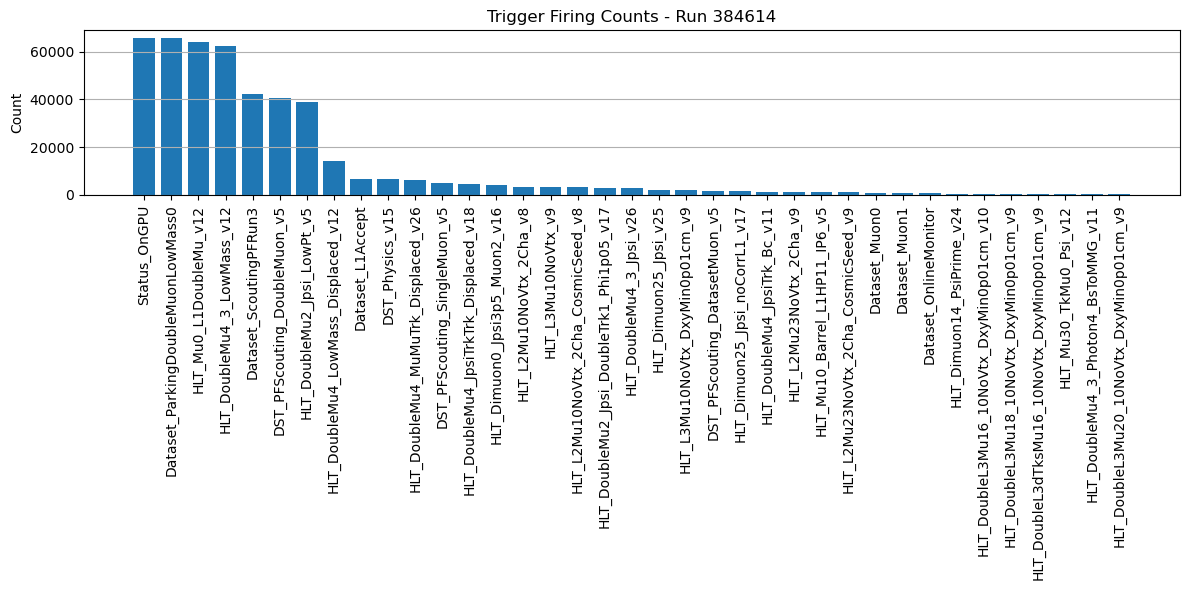

In [ ]:
# Plotting the trigger firing counts
plt.figure(figsize=(12, 6))
plt.bar(trigger_firing_count_df['TriggerName'], trigger_firing_count_df['FiringCount'])
plt.xticks(rotation=90)
plt.ylabel('Count')
plt.title('Trigger Firing Counts - Run 384614')
plt.grid(True, which='major', axis='y')
plt.tight_layout()

In [ ]:
len(final_df['LumiBlock'].unique())

50

In [ ]:
final_df['LumiBlock'].unique()

array([810, 839, 826, 808, 849, 837, 825, 822, 823, 847, 832, 833, 835,
       838, 817, 818, 831, 834, 828, 821, 815, 816, 809, 803, 840, 845,
       806, 819, 814, 820, 800, 824, 842, 836, 830, 801, 807, 802, 844,
       846, 811, 812, 804, 805, 813, 843, 829, 848, 841, 827])

In [ ]:
final_df

,Event,Run,LumiBlock,HLTriggerFirstPath,Status_OnCPU,Status_OnGPU,AlCa_EcalPhiSym_v19,AlCa_EcalEtaEBonly_v24,AlCa_EcalEtaEEonly_v24,AlCa_EcalPi0EBonly_v24,...,Dataset_ParkingSingleMuon2,Dataset_ParkingSingleMuon3,Dataset_ParkingSingleMuon4,Dataset_ParkingSingleMuon5,Dataset_ParkingSingleMuon6,Dataset_ParkingSingleMuon7,Dataset_ParkingSingleMuon8,Dataset_ParkingSingleMuon9,Dataset_ParkingSingleMuon10,Dataset_ParkingSingleMuon11
0,1827626496,384614,810,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1827269248,384614,810,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1827790464,384614,810,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1827732864,384614,810,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1827884416,384614,810,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65704,1865178880,384614,827,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
65705,1866306816,384614,827,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
65706,1864558336,384614,827,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
65707,1864569216,384614,827,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
